# AML23703 – Quantum Computing

## Tutorial 7: Deutsch's Algorithm

**Name:** LAASYA S D

**USN:** 1GA23AI021

**Department:** Artificial Intelligence and Machine Learning

**Semester:** VII

**Course Code:** AML23703

**Date:** 10-09-2026

# Objective

The objective of this tutorial is to understand and implement Deutsch's algorithm for determining whether a binary function is constant or balanced using a single quantum oracle query.

The tutorial also explores generic oracle construction, phase kickback, the effect of gate imperfections, and the conceptual application of phase kickback to binary classification.

# Theory

Deutsch's algorithm determines whether a function f(x), where x is a single-bit input, is constant or balanced.

A constant function produces the same output for both possible inputs:

f(0) = f(1)

A balanced function produces different outputs:

f(0) ≠ f(1)

The algorithm uses quantum superposition and phase kickback to determine the nature of the function with only one oracle query.

The four possible Boolean functions are:

1. f(x) = 0 — constant
2. f(x) = 1 — constant
3. f(x) = x — balanced
4. f(x) = x ⊕ 1 — balanced

The final measurement of the control qubit gives:

0 → Constant

1 → Balanced

# Exercise 1: Easy

## Question

Implement the oracle for a constant function f(x) = 0 and verify that Deutsch's algorithm outputs `0`, indicating that the function is constant.

## Aim

To implement a constant oracle for the function f(x) = 0 and verify using Deutsch's algorithm that the function is constant.

## Theory

For the constant function:

f(0) = 0

f(1) = 0

Therefore, both possible inputs produce the same output.

In Deutsch's algorithm, the control qubit is placed into superposition using a Hadamard gate. The target qubit is initialized to |1> and also placed into superposition.

For f(x) = 0, the oracle does not need any gate because the target output remains unchanged.

After applying the final Hadamard gate to the control qubit, the expected measurement is:

0 → Constant

Deutsch's Algorithm - Constant Function
Function: f(x) = 0



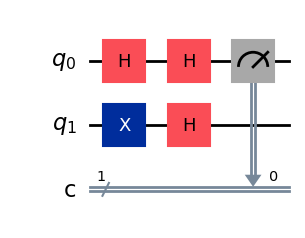

Measurement Results:
{'0': 1024}


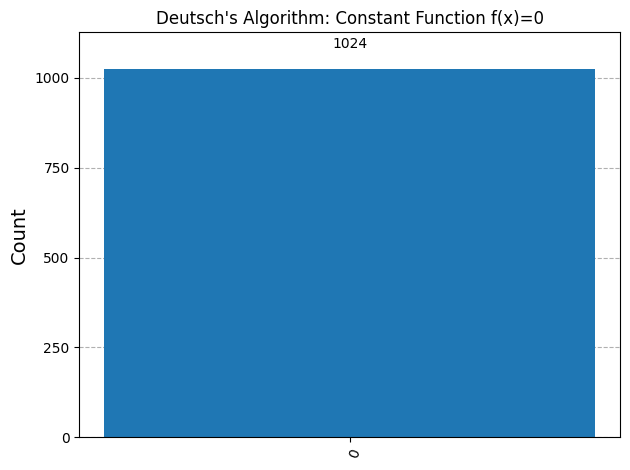

Measured Output: 0
✓ Output is 0
✓ Function is CONSTANT


In [1]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

# Create a 2-qubit circuit with 1 classical bit
qc = QuantumCircuit(2, 1)

# Prepare target qubit in |1>
qc.x(1)

# Create superposition
qc.h(0)
qc.h(1)

# Constant oracle f(x) = 0
# No gate is required

# Apply final Hadamard to control qubit
qc.h(0)

# Measure control qubit
qc.measure(0, 0)

# Display circuit
print("Deutsch's Algorithm - Constant Function")
print("Function: f(x) = 0")
print()

display(qc.draw("mpl"))

# Run simulation
simulator = AerSimulator()
compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

# Display histogram
display(
    plot_histogram(
        counts,
        title="Deutsch's Algorithm: Constant Function f(x)=0"
    )
)

# Verification
measured = list(counts.keys())[0]

print("Measured Output:", measured)

if measured == "0":
    print("✓ Output is 0")
    print("✓ Function is CONSTANT")
else:
    print("✗ Unexpected result")

## Observation

The control qubit produced the measurement outcome `0` for all 1024 shots.

This confirms that the function f(x) = 0 is constant because both possible inputs produce the same output.

## Visualization

The histogram shows that all measurement outcomes correspond to `0`.

## Conclusion

The constant oracle for f(x) = 0 was successfully implemented.

Deutsch's algorithm correctly identified the function as constant by producing the output `0`.

# Exercise 2: Medium

## Question

Implement the oracle for a balanced function f(x) = x and verify that Deutsch's algorithm outputs `1`, indicating that the function is balanced.

## Aim

To implement a balanced quantum oracle for f(x) = x using a CNOT gate and verify that Deutsch's algorithm correctly identifies the function as balanced.

## Theory

For the balanced function:

f(x) = x

the function produces different outputs for the two possible inputs:

f(0) = 0

f(1) = 1

Therefore, the function is balanced.

The oracle for f(x) = x can be implemented using a CNOT gate.

The control qubit is connected to the target qubit through the CNOT operation.

After applying the final Hadamard gate to the control qubit, the measurement gives:

0 → Constant

1 → Balanced

Therefore, the expected output for f(x) = x is `1`.

Deutsch's Algorithm - Balanced Function
Function: f(x) = x



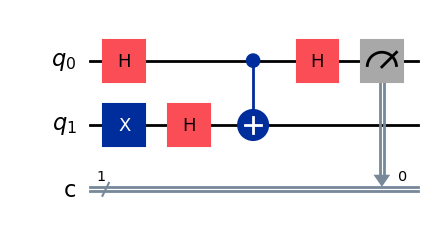

Measurement Results:
{'1': 1024}


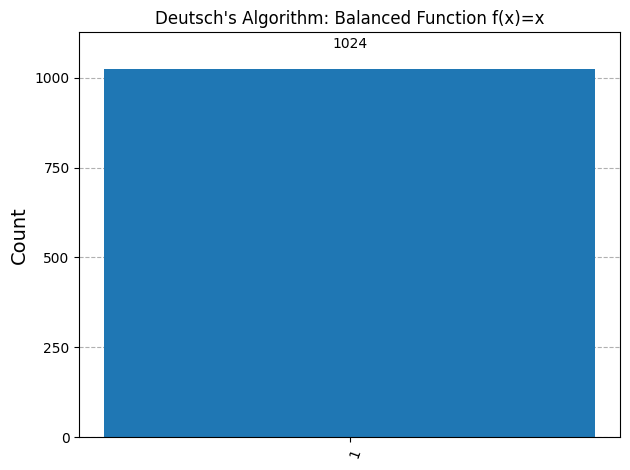

Measured Output: 1
✓ Output is 1
✓ Function is BALANCED


In [2]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt

# Create a 2-qubit circuit with 1 classical bit
qc = QuantumCircuit(2, 1)

# Prepare target qubit in |1>
qc.x(1)

# Create superposition
qc.h(0)
qc.h(1)

# Balanced oracle f(x) = x
qc.cx(0, 1)

# Apply final Hadamard to control qubit
qc.h(0)

# Measure control qubit
qc.measure(0, 0)

# Display circuit
print("Deutsch's Algorithm - Balanced Function")
print("Function: f(x) = x")
print()

display(qc.draw("mpl"))

# Run simulation
simulator = AerSimulator()
compiled = transpile(qc, simulator)

result = simulator.run(
    compiled,
    shots=1024
).result()

counts = result.get_counts()

print("Measurement Results:")
print(counts)

# Display histogram
display(
    plot_histogram(
        counts,
        title="Deutsch's Algorithm: Balanced Function f(x)=x"
    )
)

# Verification
measured = list(counts.keys())[0]

print("Measured Output:", measured)

if measured == "1":
    print("✓ Output is 1")
    print("✓ Function is BALANCED")
else:
    print("✗ Unexpected result")

## Observation

The control qubit produced the measurement outcome `1` for all 1024 shots.

This confirms that the function f(x) = x is balanced because f(0) and f(1) produce different outputs.

## Visualization

The histogram shows that all measurement outcomes correspond to `1`.

## Conclusion

The balanced oracle for f(x) = x was successfully implemented using a CNOT gate.

Deutsch's algorithm correctly identified the function as balanced by producing the output `1`.

# Exercise 3: Hard

## Question

Build a generic oracle-selection function that takes a function type as a parameter and dynamically constructs the correct oracle circuit.

## Aim

To create a generic oracle-selection function that can dynamically construct the required Deutsch oracle based on the given function type.

## Theory

Deutsch's algorithm can be applied to four possible Boolean functions:

1. f(x) = 0 — constant
2. f(x) = 1 — constant
3. f(x) = x — balanced
4. f(x) = x ⊕ 1 — balanced

Instead of creating a separate circuit for every function, a generic oracle-selection function can be used.

The function type is provided as a parameter, and the corresponding quantum gates are automatically added to the oracle circuit.

The expected Deutsch algorithm outputs are:

0 → Constant

1 → Balanced

In [3]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt


# Generic oracle-selection function
def deutsch_oracle(function_type):
    oracle = QuantumCircuit(2)

    if function_type == "constant_0":
        # f(x) = 0
        pass

    elif function_type == "constant_1":
        # f(x) = 1
        oracle.x(1)

    elif function_type == "balanced_x":
        # f(x) = x
        oracle.cx(0, 1)

    elif function_type == "balanced_not_x":
        # f(x) = x XOR 1
        oracle.cx(0, 1)
        oracle.x(1)

    else:
        raise ValueError("Invalid function type")

    return oracle


# Function to run Deutsch's algorithm
def run_deutsch(function_type, shots=1024):

    qc = QuantumCircuit(2, 1)

    # Prepare target qubit in |1>
    qc.x(1)

    # Create superposition
    qc.h(0)
    qc.h(1)

    # Add selected oracle
    oracle = deutsch_oracle(function_type)
    qc.compose(oracle, inplace=True)

    # Apply final Hadamard to control qubit
    qc.h(0)

    # Measure control qubit
    qc.measure(0, 0)

    # Run simulation
    simulator = AerSimulator()
    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    return qc, counts


# Test all four possible functions
function_types = [
    "constant_0",
    "constant_1",
    "balanced_x",
    "balanced_not_x"
]

results = {}

for function_type in function_types:

    qc, counts = run_deutsch(function_type)

    results[function_type] = counts

    print("\nFunction:", function_type)
    print("Measurement Results:", counts)

    if "0" in counts:
        print("Deutsch Output: 0")
        print("Function is CONSTANT")

    else:
        print("Deutsch Output: 1")
        print("Function is BALANCED")


Function: constant_0
Measurement Results: {'0': 1024}
Deutsch Output: 0
Function is CONSTANT

Function: constant_1
Measurement Results: {'0': 1024}
Deutsch Output: 0
Function is CONSTANT

Function: balanced_x
Measurement Results: {'1': 1024}
Deutsch Output: 1
Function is BALANCED

Function: balanced_not_x
Measurement Results: {'1': 1024}
Deutsch Output: 1
Function is BALANCED


Selected Function: balanced_x

Oracle Circuit:


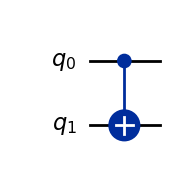

In [4]:
# Visualize the balanced oracle f(x) = x

selected_function = "balanced_x"

oracle = deutsch_oracle(selected_function)

print("Selected Function:", selected_function)
print("\nOracle Circuit:")

display(oracle.draw("mpl"))

## Observation

The generic oracle-selection function successfully constructed different oracle circuits based on the supplied function type.

The four possible Boolean functions were tested:

- f(x) = 0 produced output `0`
- f(x) = 1 produced output `0`
- f(x) = x produced output `1`
- f(x) = x ⊕ 1 produced output `1`

Therefore, the generic function correctly distinguishes between constant and balanced functions.

## Visualization

The selected oracle circuit is displayed using a quantum circuit diagram.

## Conclusion

A generic oracle-selection function was successfully implemented.

The function dynamically constructs the required oracle based on the function type, allowing Deutsch's algorithm to be tested for all four possible Boolean functions.

# Exercise 4: Real-world Application

## Question

Extend the demonstration to explain, with a simple slide/diagram, how phase kickback could conceptually apply to a binary classification decision problem.

## Aim

To understand how phase kickback can conceptually encode the result of a binary classification decision into the phase of a quantum state.

## Theory

In a binary classification problem, an input is assigned to one of two classes:

Class 0

or

Class 1

A quantum oracle can be viewed conceptually as a decision function that produces a binary output for an input.

The oracle can encode this output into the phase of the quantum state through phase kickback.

When the target qubit is prepared in the state |->, applying the oracle causes the function value to appear as a phase:

f(x) = 0 → no phase change

f(x) = 1 → phase flip

This phase information can then be processed using quantum gates and eventually converted into a measurable decision.

This provides a conceptual connection between phase kickback and binary classification.

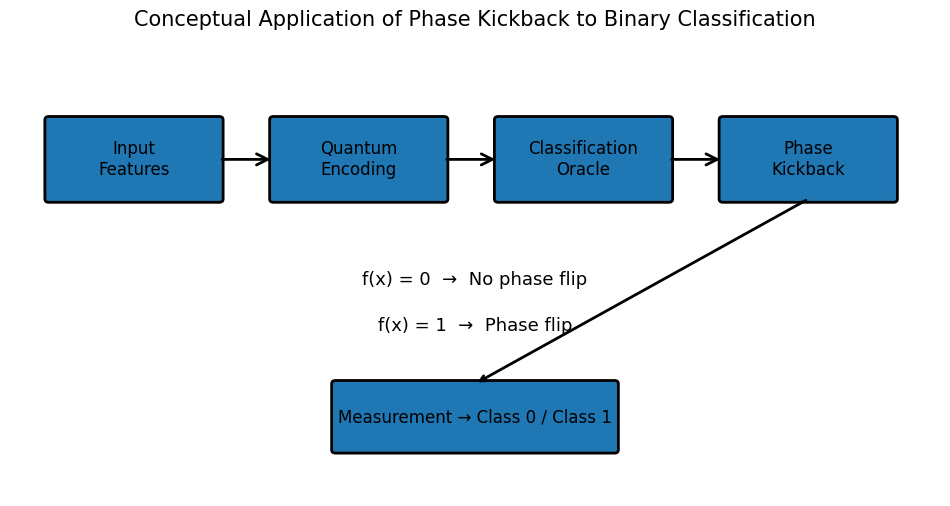

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlim(0, 12)
ax.set_ylim(0, 7)
ax.axis("off")

# Boxes
boxes = [
    (0.5, 4.5, 2.2, 1.2, "Input\nFeatures"),
    (3.4, 4.5, 2.2, 1.2, "Quantum\nEncoding"),
    (6.3, 4.5, 2.2, 1.2, "Classification\nOracle"),
    (9.2, 4.5, 2.2, 1.2, "Phase\nKickback"),
]

for x, y, w, h, text in boxes:
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.05",
        linewidth=2
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=12
    )

# Arrows
arrow_positions = [
    (2.7, 5.1, 3.4, 5.1),
    (5.6, 5.1, 6.3, 5.1),
    (8.5, 5.1, 9.2, 5.1)
]

for x1, y1, x2, y2 in arrow_positions:
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1),
            (x2, y2),
            arrowstyle="->",
            mutation_scale=20,
            linewidth=2
        )
    )

# Phase information
ax.text(
    6,
    3.2,
    "f(x) = 0  →  No phase flip",
    ha="center",
    fontsize=13
)

ax.text(
    6,
    2.5,
    "f(x) = 1  →  Phase flip",
    ha="center",
    fontsize=13
)

# Final decision
decision_box = FancyBboxPatch(
    (4.2, 0.7),
    3.6,
    1.0,
    boxstyle="round,pad=0.05",
    linewidth=2
)

ax.add_patch(decision_box)

ax.text(
    6,
    1.2,
    "Measurement → Class 0 / Class 1",
    ha="center",
    va="center",
    fontsize=12
)

ax.annotate(
    "",
    xy=(6, 1.7),
    xytext=(10.3, 4.5),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=2
    )
)

ax.set_title(
    "Conceptual Application of Phase Kickback to Binary Classification",
    fontsize=15
)

plt.show()

## Observation

The diagram demonstrates a conceptual workflow for applying phase kickback to a binary classification decision.

The classification oracle represents a binary decision function. Its output can be encoded into the phase of a quantum state using phase kickback.

For a classification output of 0, there is no phase flip.

For a classification output of 1, the quantum state experiences a phase flip.

## Visualization

The diagram shows the conceptual flow:

Input Features → Quantum Encoding → Classification Oracle → Phase Kickback → Measurement → Class 0 / Class 1

## Conclusion

Phase kickback provides a mechanism for encoding the output of a binary function into quantum phase.

Although this example is conceptual rather than a practical machine-learning classifier, it demonstrates how quantum oracles and phase information can be related to binary decision problems.

# Exercise 5: Challenge

## Question

Modify the Deutsch's algorithm circuit to introduce a deliberate small gate error in the Hadamard operation and study how the measurement outcome reliability degrades. Quantify the degradation using a bar chart.

## Aim

To study the effect of a small Hadamard gate error on the reliability of Deutsch's algorithm and visualize the change in measurement accuracy.

## Theory

In an ideal quantum circuit, the Hadamard gate creates and recombines quantum superposition accurately.

In a real quantum system, gates can have small imperfections. These imperfections can introduce phase errors and affect the final measurement probabilities.

In this experiment, a small phase error is deliberately added after each Hadamard gate.

The experiment is performed for different error values.

The reliability is calculated as the percentage of measurements that produce the expected Deutsch's algorithm output.

For the constant function f(x) = 0, the expected output is:

0 → Constant

As the gate error increases, the probability of obtaining the expected output can decrease.

A bar chart is used to visualize the effect of the gate error on measurement reliability.

In [8]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


# Function to apply an imperfect Hadamard gate
def imperfect_hadamard(qc, qubit, error):
    qc.h(qubit)
    qc.rz(error, qubit)


# Run Deutsch's algorithm with a deliberate Hadamard error
def run_with_error(error, shots=4096):

    qc = QuantumCircuit(2, 1)

    # Prepare target qubit in |1>
    qc.x(1)

    # First imperfect Hadamard gates
    imperfect_hadamard(qc, 0, error)
    imperfect_hadamard(qc, 1, error)

    # Constant oracle f(x) = 0
    # No oracle gate is required

    # Final imperfect Hadamard on control
    imperfect_hadamard(qc, 0, error)

    # Measure control qubit
    qc.measure(0, 0)

    # Run simulation
    simulator = AerSimulator()
    compiled = transpile(qc, simulator)

    result = simulator.run(
        compiled,
        shots=shots
    ).result()

    counts = result.get_counts()

    return counts


# Different error values in radians
errors = [0, 0.05, 0.10, 0.20, 0.30]

reliability = []

for error in errors:

    counts = run_with_error(error)

    correct = counts.get("0", 0)

    accuracy = (correct / 4096) * 100

    reliability.append(accuracy)

    print(
        f"Error = {error:.2f} radians | "
        f"Results = {counts} | "
        f"Reliability = {accuracy:.2f}%"
    )

Error = 0.00 radians | Results = {'0': 4096} | Reliability = 100.00%
Error = 0.05 radians | Results = {'0': 4092, '1': 4} | Reliability = 99.90%
Error = 0.10 radians | Results = {'0': 4090, '1': 6} | Reliability = 99.85%
Error = 0.20 radians | Results = {'0': 4049, '1': 47} | Reliability = 98.85%
Error = 0.30 radians | Results = {'0': 3995, '1': 101} | Reliability = 97.53%


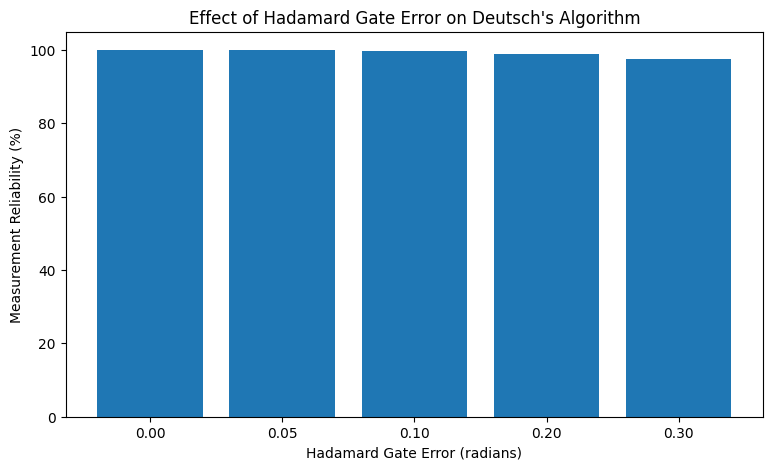

In [9]:
plt.figure(figsize=(9, 5))

labels = [
    "0.00",
    "0.05",
    "0.10",
    "0.20",
    "0.30"
]

plt.bar(labels, reliability)

plt.xlabel("Hadamard Gate Error (radians)")
plt.ylabel("Measurement Reliability (%)")
plt.title("Effect of Hadamard Gate Error on Deutsch's Algorithm")
plt.ylim(0, 105)

plt.show()

## Observation

With no gate error, Deutsch's algorithm produces the expected output `0` with approximately 100% reliability.

When a small phase error is introduced after the Hadamard gates, some measurements can produce an incorrect result.

As the magnitude of the error increases, the measurement reliability decreases.

The bar chart clearly demonstrates the effect of gate imperfections on the accuracy of the quantum algorithm.

## Visualization

The bar chart shows the relationship between the Hadamard gate error and measurement reliability.

A larger gate error results in a lower probability of obtaining the expected output.

## Conclusion

A deliberate small error was introduced into the Hadamard gates of Deutsch's algorithm.

The experiment demonstrated that quantum gate imperfections can reduce measurement reliability.

The effect was quantified using repeated measurements and represented using a bar chart.

# Reflection Questions

## 1. Why is Deutsch's algorithm historically significant despite its limited practical use?

Deutsch's algorithm is historically significant because it was one of the earliest quantum algorithms to demonstrate that a quantum computer can solve a computational problem with fewer function evaluations than a deterministic classical computer.

For a single-bit Boolean function, a classical deterministic method may require two evaluations in the worst case, while Deutsch's algorithm can determine whether the function is constant or balanced using one quantum oracle query.

The algorithm introduced important concepts such as quantum superposition, interference, and phase kickback, which became fundamental ideas in later quantum algorithms.

Although the problem itself has limited practical application, the algorithm is important as a demonstration of quantum computational advantage.

## 2. How does phase kickback allow information about f(x) to appear in the control qubit's phase?

In Deutsch's algorithm, the target qubit is prepared in the state |->.

When the oracle applies the transformation:

|y> → |y ⊕ f(x)>

to this target state, the result introduces a phase:

(-1)^f(x)

Therefore:

f(x) = 0 → no phase change

f(x) = 1 → phase flip

The value of f(x) is therefore encoded into the phase associated with the control qubit's state.

The final Hadamard gate converts this phase information into an observable measurement outcome:

0 → Constant

1 → Balanced

Thus, phase kickback allows information about the function to influence the control qubit without directly measuring the target qubit.